# Crystallizer: a crystal structure from the diffusion density

This notebook shows how to use the [`Crystallizer`][gemdat.crystallizer.Crystallizer] to
reconstruct a symmetry-fitted crystal structure (and a CIF file) from the occupancy density
of a molecular dynamics trajectory.

The pipeline is:

1. Load a trajectory and identify the diffusing species.
2. Turn its positions into an occupancy **density** volume.
3. Segment the density into candidate **sites** with partial occupancies.
4. Combine the sites with the time-averaged host framework and fit the highest space group.

Here we use the same Na&#8323;(Sb/W)S&#8324; run as the
[shape-analysis tutorial](../tutorials/gemdat_basic_analysis.ipynb): 46 sodium ions
diffusing through an Sb/W&ndash;S framework, simulated at 500&nbsp;K for 25&nbsp;000 frames.
The simulation cell (&#8776;14.4&nbsp;&#197;) is a 2&times;2&times;2 supercell of the
&#8776;7.2&nbsp;&#197; conventional cell, so it holds eight copies of the conventional cell.

In [1]:
import plotly.io as pio

# Render plotly figures as static HTML so they display on the docs website
pio.renderers.default = 'plotly_mimetype+notebook_connected'

from gemdat import Trajectory
from gemdat.plots import plot_3d

# Same Na3(Sb/W)S4 AIMD run as the shape-analysis tutorial. The data lives in the
# `tests/data` submodule (run `git submodule update --init`); the paths below are
# relative to this notebook.
# `from_vasprun` loads the parse cache directly when it exists, so the (large)
# raw vasprun.xml is not actually needed here.
DATA = '../../tests/data/na3sbs4'
VASPRUN = f'{DATA}/vasprun.xml'

trajectory = Trajectory.from_vasprun(VASPRUN, cache=f'{DATA}/vasprun.xml.a45e320a.cache')
trajectory

Full Formula (Na46 Sb14 W2 S64)
Reduced Formula: Na23Sb7WS32
abc   :  14.437000  14.437028  14.475216
angles:  90.000427  89.999751  90.237694
pbc   :       True       True       True
Constant lattice (True)
Sites (126)
Time steps (25000)

Keep only the diffusing species, sodium.

In [2]:
diff_trajectory = trajectory.filter('Na')
diff_trajectory

Full Formula (Na46)
Reduced Formula: Na
abc   :  14.437000  14.437028  14.475216
angles:  90.000427  89.999751  90.237694
pbc   :       True       True       True
Constant lattice (True)
Sites (46)
Time steps (25000)

## The occupancy density

The diffusing sodium visits its (meta-)stable sites over and over, so its time-averaged
density already traces out the sodium sublattice. We bin the positions onto a voxel grid
with [`Trajectory.to_volume`][gemdat.Trajectory.to_volume].

In [3]:
resolution = 0.3  # Å

vol = diff_trajectory.to_volume(resolution=resolution)
vol

Data: (48, 48, 48)
Lattice, abc:  14.437000  14.437028  14.475216
      angles:  90.000427  89.999751  90.237694
         pbc:       True       True       True
Label: trajectory

The density projected onto the three principal planes (summed over the remaining axis).
The repeating 2&times;2&times;2 pattern of the supercell is clearly visible: the same set of
sodium sites recurs across each copy of the conventional cell.

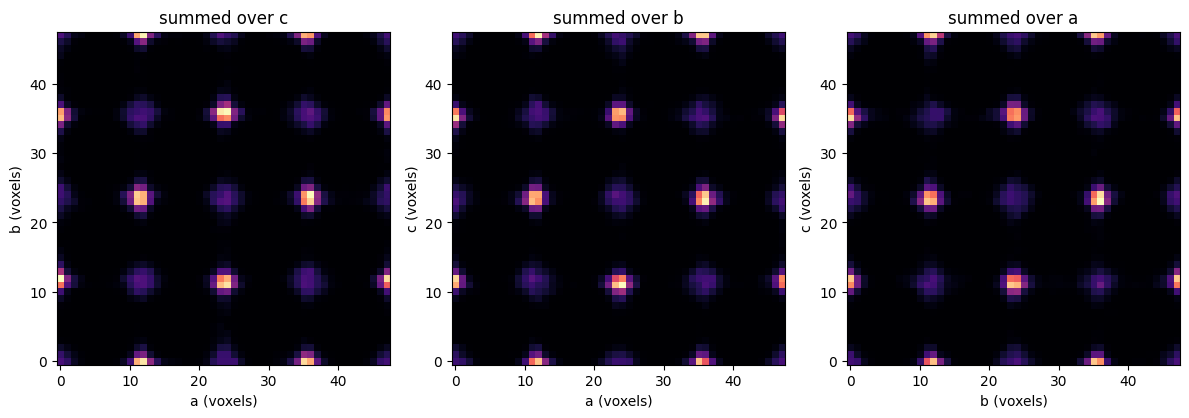

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, axis, (xlabel, ylabel) in zip(axes, (2, 1, 0), (('a', 'b'), ('a', 'c'), ('b', 'c'))):
    ax.imshow(vol.data.sum(axis=axis).T, origin='lower', aspect='equal', cmap='magma')
    ax.set_title(f'summed over {"abc"[axis]}')
    ax.set_xlabel(f'{xlabel} (voxels)')
    ax.set_ylabel(f'{ylabel} (voxels)')

fig.tight_layout()

## Finding the sites

We build the [`Crystallizer`][gemdat.crystallizer.Crystallizer] from the **full** trajectory
(so the Sb/W&ndash;S framework is available later) and tell it which species is mobile.
[`Crystallizer.mobile_sites`][gemdat.crystallizer.Crystallizer.mobile_sites] segments the
sodium density into discrete sites with partial occupancies using a watershed algorithm.

How many sites are found is controlled by a few knobs (passed through to
[`Volume.find_peaks`][gemdat.Volume.find_peaks] / the watershed):

- **`background_level`** &mdash; fraction of the peak density used as the segmentation floor.
  This is the main knob: raising it trims weak, spurious basins (and shrinks the basins,
  keeping occupancies well below 1).
- **`resolution`** &mdash; the voxel size set above. Too fine over-segments each site into
  several basins; too coarse merges neighbouring sites.
- **`threshold`** &mdash; the difference-of-Gaussian peak-detection threshold (passed to
  `find_peaks`); raise it to drop faint peaks.

The conventional cell carries 6 sodium positions, so the 2&times;2&times;2 supercell has 48
ideal sodium sites. With `background_level=0.25` the watershed lands exactly on those 48: a
site sitting on a cell face would otherwise be detected twice (once just inside each side of
the boundary), but `find_peaks` merges these periodic-image duplicates so it is reported once.

We also pass the optional `snap_to_lower=True`, which reports a site sitting on a face at the
lower end of the axis (~0) rather than just below 1. It trades a little (sub-voxel) precision
for a consistent representation, so it is off by default.

In [5]:
from gemdat.crystallizer import Crystallizer

background_level = 0.25

cr = Crystallizer.from_trajectory(trajectory, floating_specie='Na', resolution=resolution)

sites = cr.mobile_sites(background_level=background_level, snap_to_lower=True)

# `mobile_sites` labels each site by species *and* occupancy (e.g. 'Na:0.42'),
# which makes every site a distinct label. Relabel to the plain element so the
# occupancy doesn't leak into the site labels (and the plot colours by element).
for site in sites:
    site.label = 'Na'

print(f'found {len(sites)} sodium sites (ideal supercell has 48)')
print(f'max occupancy: {max(s.species.num_atoms for s in sites):.2f}')
sites[:5]

found 48 sodium sites (ideal supercell has 48)
max occupancy: 0.56


[PeriodicSite: Na (Na:0.338) (0.02771, 7.369, 10.79) [0.002976, 0.5104, 0.7455],
 PeriodicSite: Na (Na:0.427) (-0.02242, 10.82, 10.67) [0.0, 0.7494, 0.7371],
 PeriodicSite: Na (Na:0.418) (3.611, 7.244, -1.908e-05) [0.2512, 0.5023, 0.0],
 PeriodicSite: Na (Na:0.438) (3.704, 10.64, -3.147e-05) [0.2581, 0.7373, 0.0],
 PeriodicSite: Na (Na:0.437) (7.196, 10.81, -2.456e-05) [0.5, 0.75, 0.0]]

Overlaying the sites (red) on the sodium density isosurface.

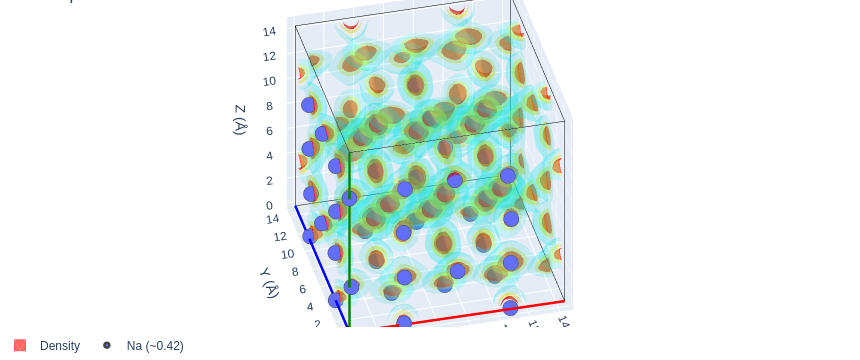

In [6]:
vol.plot_3d(structure=sites)

## Comparison with the expected sites

The workshop reference `structure_1.cif` describes the conventional, cubic *I*-43*m*
Na&#8323;(Sb/W)S&#8324; with the sodium spread over a single (disordered) Wyckoff site.
Expanded to the 2&times;2&times;2 MD supercell it lists 48 ideal sodium positions. Overlaying
them on the density shows how well the simulation reproduces the known sodium sublattice.

reference sodium sites: 48


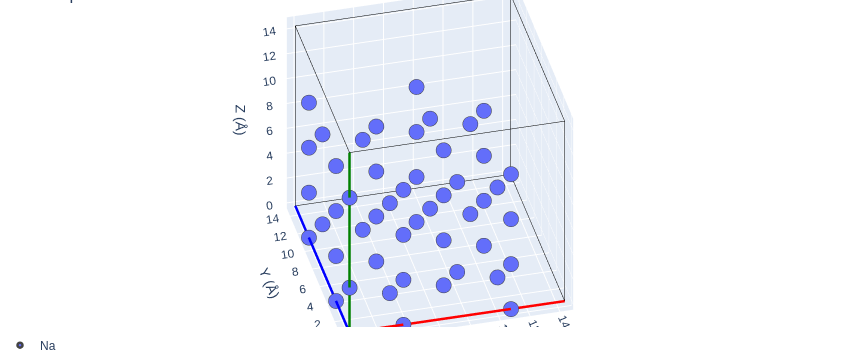

In [7]:
from pymatgen.core import Structure

from gemdat.io import read_cif

# Conventional I-43m reference, expanded to the 2x2x2 MD supercell and stripped
# down to the sodium sublattice. Place the sites in the volume's lattice so they
# share its coordinate frame.
reference = read_cif(f'{DATA}/structure_1.cif')
reference.make_supercell((2, 2, 2))
reference.remove_species(['S', 'Sb', 'W'])

expected_sites = Structure(
    lattice=vol.lattice,
    species=[site.species.elements[0] for site in reference],
    coords=[site.frac_coords for site in reference],
)

print(f'reference sodium sites: {len(expected_sites)}')
plot_3d(structure=expected_sites)

## Crystallize

Finally, [`Crystallizer.scan`][gemdat.crystallizer.Crystallizer.scan] combines the mobile
sodium sites with the time-averaged Sb/W&ndash;S framework and works out which space groups
that structure can adopt, over a range of symmetry tolerances. It hands back a
[`CrystallizerScan`][gemdat.crystallizer.CrystallizerScan] &mdash; the reconstructed geometry
together with its symmetry ranking &mdash; and
[`best`][gemdat.crystallizer.CrystallizerScan.best] crystallizes the highest space group in
it. The same `background_level` is forwarded to the site segmentation.

Keeping the scan is what lets us come back for the other space groups further down without
redoing any of the density work. If only the winner is wanted,
[`crystallize`][gemdat.crystallizer.Crystallizer.crystallize] is that pair of calls in one.

In [8]:
scan = cr.scan(background_level=background_level)
result = scan.best()

result.to_cif('na3sbs4_crystallized.cif')

print(f'space group: {result.spacegroup_symbol} (#{result.spacegroup_number})')
print(f'symprec:     {result.symprec} Å')
print(f'sites:       {len(result.structure)}')

space group: I-43m (#217)
symprec:     0.4522792578836114 Å
sites:       128


The result can be written straight to a CIF file with the fitted symmetry, either from the
result itself or, in one step, from the crystallizer:

```python
result.to_cif('na3sbs4_crystallized.cif')  # writes the fit computed above
cr.to_cif('na3sbs4_crystallized.cif', background_level=background_level)  # fits and writes
```

> **Note.** Even for this thermally noisy, W-doped and site-disordered run, the Crystallizer
> recovers the ideal cubic *I*-43*m* (#217) symmetry of Na&#8323;(Sb/W)S&#8324; &mdash; with
> all 48 sodium positions of the supercell &mdash; but only at a loose symmetry tolerance
> (`symprec = 0.5` &#197;). The density-derived site centroids scatter by a few tenths of an
> &#197;ngstr&ouml;m around the ideal Wyckoff positions, so a tight tolerance would treat
> them as inequivalent and collapse the fit to P1. The scan covers a range of tolerances, so
> `best` can report the highest symmetry that is justifiable from the data.

## How much tolerance did that take?

[`CrystallizerScan.format`][gemdat.crystallizer.CrystallizerScan.format] prints all found possible space groups 
the geometry can adopt. Which sub-symmetry the data supports, at what
precision, and how many symmetry-distinct site orbits are left. while
[`candidates`][gemdat.crystallizer.CrystallizerScan.candidates] lists those same space groups
ranked by symmetry, each with the *tightest* tolerance that still reaches it.

In [9]:
print(scan.format())

print('\ndistinct space groups found (tightest symprec each):')
for level in scan.candidates:
    print(
        f'  #{level.spacegroup_number:<4}{level.spacegroup_symbol:<7}'
        f'at symprec = {level.symprec} Å  ({level.n_site_orbits} site orbits)'
    )

symprec (Å)  deviation (Å)  angle dev (°)  space group  #    crystal system  # ops  # orbits  # hits
-----------  -------------  -------------  -----------  ---  --------------  -----  --------  ------
0.01         0              0              P1           1    triclinic       1      128       31    
0.224111     0.2034         0.119          Cc           9    monoclinic      2      64        3     
0.302798     0.3137         0.119          Cm           8    monoclinic      4      40        4     
0.452279     0.556          0.238          I-43m        217  cubic           48     10        2     

distinct space groups found (tightest symprec each):
  #217 I-43m  at symprec = 0.4522792578836114 Å  (10 site orbits)
  #9   Cc     at symprec = 0.22411108428063742 Å  (64 site orbits)
  #8   Cm     at symprec = 0.3027982334416631 Å  (40 site orbits)
  #1   P1     at symprec = 0.01 Å  (128 site orbits)


So the density-derived structure only becomes cubic once the tolerance is loose enough to
absorb the thermal scatter of the site centroids: on the way up from P1 it passes through
two monoclinic spacegroups, *Cc* at 0.22&nbsp;&#197; and *Cm* at 0.30&nbsp;&#197;, before reaching
*I*-43*m* at 0.45&nbsp;&#197;. The `deviation` column says what the minimal deviation required is to
find that symmetry exactly &mdash; which, unlike `symprec`,
is a property of the structure rather than of the search.

Knowing the ranking, the outcome can also be pinned instead of taking the highest symmetry.
[`at_spacegroup`][gemdat.crystallizer.CrystallizerScan.at_spacegroup] crystallizes a space
group by name, at the tightest tolerance in the scan that still reaches it (matched by
international number or Hermann&ndash;Mauguin symbol), while
[`Crystallizer.crystallize_at`][gemdat.crystallizer.Crystallizer.crystallize_at] skips the
scan altogether and fits at exactly the tolerance given.

In [10]:
monoclinic = scan.at_spacegroup('Cm')
tight = cr.crystallize_at(0.1, background_level=background_level)

for name, res in ('target Cm', monoclinic), ('symprec=0.1', tight):
    print(
        f'{name:<12} -> {res.spacegroup_symbol} (#{res.spacegroup_number}) '
        f'at symprec = {res.symprec} Å'
    )

target Cm    -> Cm (#8) at symprec = 0.3027982334416631 Å
symprec=0.1  -> P1 (#1) at symprec = 0.1 Å


### A CIF for every symmetry that was found

A row of the ranking can also be handed straight back to
[`at_level`][gemdat.crystallizer.CrystallizerScan.at_level], which fits at exactly the
tolerance that row reports &mdash; so there is no need to translate a space group off the
table back into a `symprec`. Letting each result write itself with
[`to_cif`][gemdat.crystallizer.CrystallizerResult.to_cif] gives one file per symmetry the scan
found, which is the practical way to compare them in a viewer or hand them to a refinement.

The geometry (density peaks + averaged framework) belongs to the scan, so only the symmetry
fit is repeated per file.

In [11]:
from pathlib import Path

outdir = Path('na3sbs4_symmetries')
outdir.mkdir(exist_ok=True)

for level in scan.candidates:
    # Hermann-Mauguin symbols can contain a '/' (e.g. P2_1/c), which is not a filename.
    symbol = level.spacegroup_symbol.replace('/', '_')
    filename = outdir / f'na3sbs4_{level.spacegroup_number}_{symbol}.cif'

    written = scan.at_level(level)
    written.to_cif(filename)

    print(
        f'{filename.name:<24} {written.spacegroup_symbol:<6} '
        f'(#{written.spacegroup_number:<3}) symprec = {written.symprec:<6.3g} Å  '
        f'deviation = {level.deviation:.3g} Å  {len(written.structure)} sites'
    )

na3sbs4_217_I-43m.cif    I-43m  (#217) symprec = 0.452  Å  deviation = 0.556 Å  128 sites
na3sbs4_9_Cc.cif         Cc     (#9  ) symprec = 0.224  Å  deviation = 0.203 Å  128 sites
na3sbs4_8_Cm.cif         Cm     (#8  ) symprec = 0.303  Å  deviation = 0.314 Å  128 sites
na3sbs4_1_P1.cif         P1     (#1  ) symprec = 0.01   Å  deviation = 0 Å  128 sites


## The crystallized structure

Finally, reading the CIF we just wrote back in and plotting it shows the symmetry-fitted
structure on its own &mdash; the Sb/W&ndash;S framework together with the partial-occupancy
sodium sublattice

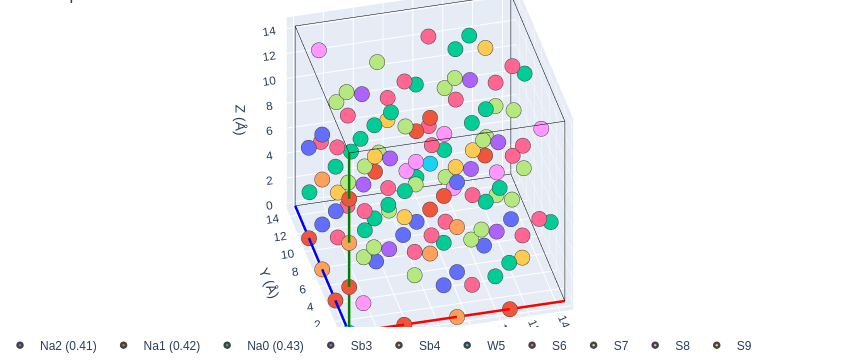

In [12]:
# Read the CIF written above back in and plot the symmetry-fitted structure on
# its own (framework + partial-occupancy sodium), without the underlying
# density. The sodium occupancies are summarised per site type in the legend.
crystallized = read_cif('na3sbs4_crystallized.cif')
plot_3d(structure=crystallized)